In [1]:
#Importing basic libraries
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#loading dataset
data = pd.read_csv("DNN-EdgeIIoT-dataset (1).csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_8480\3738999008.py:2: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("DNN-EdgeIIoT-dataset (1).csv")


In [4]:
#Converting mixed type columns to consistent types
#List of columns with mixed types
mixed_cols = [2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55]
# Convert to string
for col in mixed_cols:
    data.iloc[:, col] = data.iloc[:, col].astype(str)


In [5]:
# Detect all object/string columns
object_cols = data.select_dtypes(include=['object']).columns

# Encode them to numeric
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # save encoder to reverse transform later


In [6]:
print(data.dtypes)  
print(data.head())


frame.time              int32
ip.src_host             int32
ip.dst_host             int32
arp.dst.proto_ipv4      int32
arp.opcode            float64
                       ...   
mbtcp.len             float64
mbtcp.trans_id        float64
mbtcp.unit_id         float64
Attack_label            int64
Attack_type             int32
Length: 63, dtype: object
   frame.time  ip.src_host  ip.dst_host  arp.dst.proto_ipv4  arp.opcode  \
0       57650        58101        22987                   0         0.0   
1       57651        58100        22988                   0         0.0   
2       57652        58101        22987                   0         0.0   
3       57653        58101        22987                   0         0.0   
4       57654        58100        22988                   0         0.0   

   arp.hw.size  arp.src.proto_ipv4  icmp.checksum  icmp.seq_le  \
0          0.0                   0            0.0          0.0   
1          0.0                   0            0.0          0.

In [7]:
# Remove columns that contain only a single unique value
constant_columns = [col for col in data.columns if data[col].nunique() <= 1]

print("Removing constant columns:", constant_columns)

data = data.drop(columns=constant_columns)

Removing constant columns: ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']


In [8]:
#Seperating features and Labels
X = data.drop(['Attack_label','Attack_type'], axis=1)
y_label = data['Attack_label']
y_type = data['Attack_type']

In [9]:
X_train, X_temp, ylabel_train, ylabel_temp, ytype_train, ytype_temp = train_test_split(X, y_label, y_type, test_size = 0.2, random_state =42)

In [10]:
X_val,X_test,ylabel_val,ylabel_test,ytype_val,ytype_test = train_test_split(X_temp,ylabel_temp,ytype_temp, test_size=0.5, random_state=42)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [12]:
train_rows = X_train.shape[0]
val_rows = X_val.shape[0]
test_rows = X_test.shape[0]

In [13]:
print( train_rows, val_rows, test_rows)

1775360 221920 221921


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_label = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model_label.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history1 = model_label.fit(
    X_train, ylabel_train,
    validation_data =(X_val, ylabel_val),
    epochs=10,
    batch_size=300
)

Epoch 1/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 4.4381e-04
Epoch 2/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 1.0000 - loss: 3.9742e-05 - val_accuracy: 1.0000 - val_loss: 6.3522e-04
Epoch 3/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 1.0000 - loss: 1.3680e-05 - val_accuracy: 1.0000 - val_loss: 6.9193e-04
Epoch 4/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 1.0000 - loss: 2.3254e-05 - val_accuracy: 1.0000 - val_loss: 7.3835e-04
Epoch 5/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 1.0000 - loss: 1.1305e-06 - val_accuracy: 1.0000 - val_loss: 7.6111e-04
Epoch 6/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 1.0000 - loss: 5.1554e-06 - val_accuracy: 1.0000 - val_loss: 8.7064e-04
Epoch 7/10
5918/5918 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 1.0000 - loss: 1.4283e-06 - val_accuracy: 1.0000 - val_loss: 9.2077e-04
Epoch 8/10
5918/5918 ━━━━━━━━━━

In [17]:
from sklearn.metrics import accuracy_score
# Get raw prediction probabilities
ytrain_pred_prob = model_label.predict(X_train)

# Convert probabilities to 0/1 predictions using threshold 0.5
ytrain_pred = (ytrain_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy_train = accuracy_score(ylabel_train, ytrain_pred)

print("Stage 1 Train Accuracy:", accuracy_train)





55480/55480 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step
Stage 1 Train Accuracy: 1.0


In [18]:
# Get raw prediction probabilities
yval_pred_prob = model_label.predict(X_val)

# Convert probabilities to 0/1 predictions using threshold 0.5
yval_pred = (yval_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy_val = accuracy_score(ylabel_val, yval_pred)

print("Stage 1 Val Accuracy:", accuracy_val)



6935/6935 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
Stage 1 Val Accuracy: 0.9999954938716654


In [19]:
# Get raw prediction probabilities
ytest_pred_prob = model_label.predict(X_test)

# Convert probabilities to 0/1 predictions using threshold 0.5
ytest_pred = (ytest_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy_test = accuracy_score(ylabel_test, ytest_pred)

print("Stage 1 Test Accuracy:", accuracy_test)

6936/6936 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Stage 1 Test Accuracy: 1.0


In [20]:
print(ytrain_pred)

[[0]
 [0]
 [0]
 ...
 [0]
 [1]
 [1]]


In [21]:
attack_indices_train = np.where(ylabel_train == 1)[0]
attack_indices_val = np.where(ylabel_val == 1)[0]
attack_indices_test = np.where(ylabel_test == 1)[0]

In [22]:
print(attack_indices_train)
print(attack_indices_val)
print(attack_indices_test)

[      3       4       6 ... 1775354 1775358 1775359]
[     3      6     10 ... 221905 221907 221910]
[     4      5      6 ... 221915 221916 221919]


In [23]:
X_train_attack = X_train[attack_indices_train]
X_val_attack = X_val[attack_indices_val]
X_test_attack = X_test[attack_indices_test]

In [24]:
y_train_attack = ytype_train.iloc[attack_indices_train]
y_val_attack = ytype_val.iloc[attack_indices_val]
y_test_attack = ytype_test.iloc[attack_indices_test]

In [25]:
print(y_train_attack)

1795047     3
1917770    13
2056272     4
2120328     2
1955570     0
           ..
1766891     3
2138242     2
2003274     4
1692743    11
2219110     2
Name: Attack_type, Length: 483022, dtype: int32


In [26]:

from tensorflow.keras.utils import to_categorical

In [27]:
y_train_attack_encoded = le.fit_transform(y_train_attack)
y_val_attack_encoded = le.transform(y_val_attack)
y_test_attack_encoded = le.transform(y_test_attack)

In [28]:
num_classes = len(le.classes_)
y_train_attack_cat = to_categorical(y_train_attack_encoded, num_classes)
y_val_attack_cat = to_categorical(y_val_attack_encoded, num_classes)
y_test_attack_cat = to_categorical(y_test_attack_encoded, num_classes)


In [29]:
print(y_train_attack_cat)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_dim = X_train_attack.shape[1]

model_type = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_type.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_type.summary()


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │           7,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,590 (64.80 KB)

 Trainable params: 16,590 (64.80 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_2 = model_type.fit(
    X_train_attack,
    y_train_attack_cat,
    validation_data=(X_val_attack, y_val_attack_cat),
    epochs=20,
    batch_size=256,
    verbose=1
)


Epoch 1/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9485 - loss: 0.1689 - val_accuracy: 0.9952 - val_loss: 0.0181
Epoch 2/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accuracy: 0.9971 - val_loss: 0.0120
Epoch 3/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9977 - val_loss: 0.0116
Epoch 4/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9957 - loss: 0.0128 - val_accuracy: 0.9981 - val_loss: 0.0105
Epoch 5/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9981 - val_loss: 0.0105
Epoch 6/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9967 - loss: 0.0093 - val_accuracy: 0.9985 - val_loss: 0.0096
Epoch 7/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9986 - val_loss: 0.0096
Epoch 8/20
1887/1887 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9972 - loss: 0.0077 -

In [32]:
test_loss, test_acc = model_type.evaluate(X_test_attack, y_test_attack_cat)
print("Second model test accuracy:", test_acc)


1886/1886 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9987 - loss: 0.0031
Second model test accuracy: 0.9986742734909058


In [33]:
binary_preds = model_label.predict(X_test)
binary_preds_labels = (binary_preds > 0.5).astype(int).flatten()

6936/6936 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


In [34]:
attack_test_indices = np.where(binary_preds_labels == 1)[0]
X_test_attack = X_test[attack_test_indices]

In [35]:
attack_type_probs = model_type.predict(X_test_attack)
attack_type_pred_labels = np.argmax(attack_type_probs, axis=1)
attack_type_names = le.inverse_transform(attack_type_pred_labels)


1886/1886 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [36]:
final_output = ["Normal"] * len(X_test)

for idx, attack_name in zip(attack_test_indices, attack_type_names):
    final_output[idx] = attack_name


In [38]:
y_true_final = np.where(ylabel_test == 0, "Normal", ytype_test)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true_final, final_output)
print("Overall Accuracy:", accuracy)


Overall Accuracy: 0.9996395113576453


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_true_final, final_output, zero_division=0))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2413
           1       1.00      1.00      1.00      5098
          10       0.99      0.99      0.99      1076
          11       1.00      1.00      1.00      5089
          12       1.00      1.00      1.00      3871
          13       1.00      1.00      1.00      4963
          14       1.00      1.00      1.00      1647
           2       1.00      1.00      1.00     11576
           3       1.00      1.00      1.00      5077
           4       1.00      1.00      1.00     12121
           5       1.00      0.99      0.99        85
           6       1.00      1.00      1.00       129
           8       1.00      1.00      1.00      4956
           9       0.98      0.99      0.99      2244
      Normal       1.00      1.00      1.00    161576

    accuracy                           1.00    221921
   macro avg       1.00      1.00      1.00    221921
weighted avg       1.00   

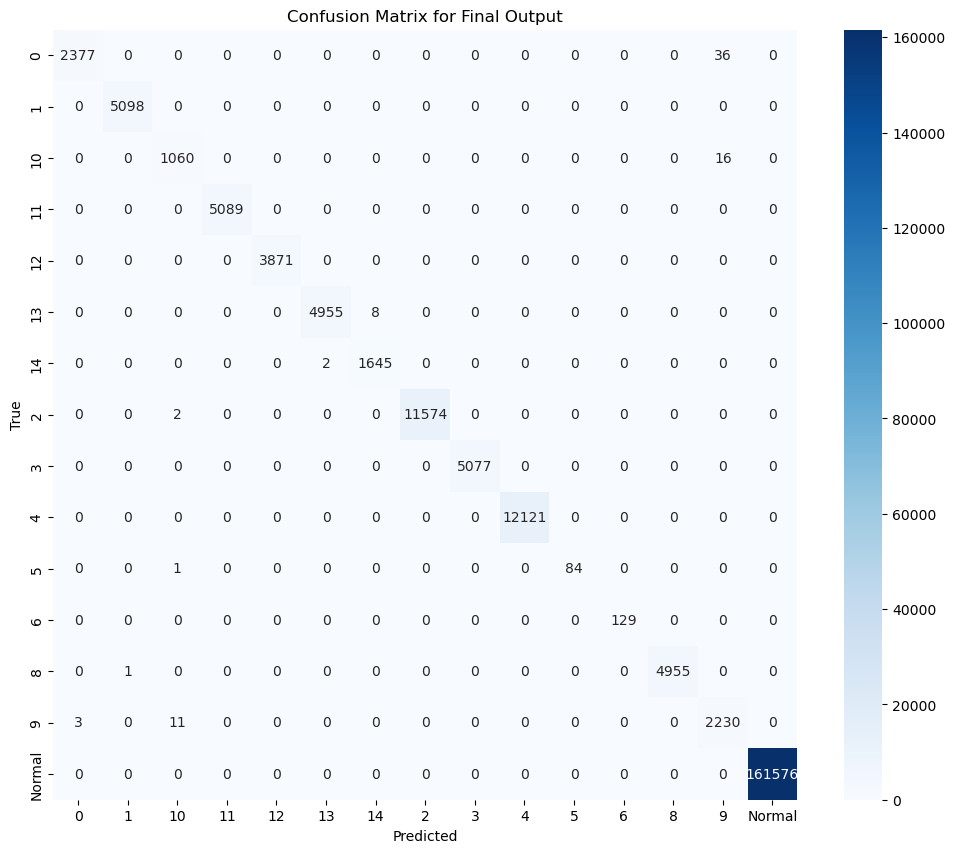

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_final, final_output, labels=np.unique(y_true_final))

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y_true_final),
            yticklabels=np.unique(y_true_final), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Final Output")
plt.show()


1886/1886 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


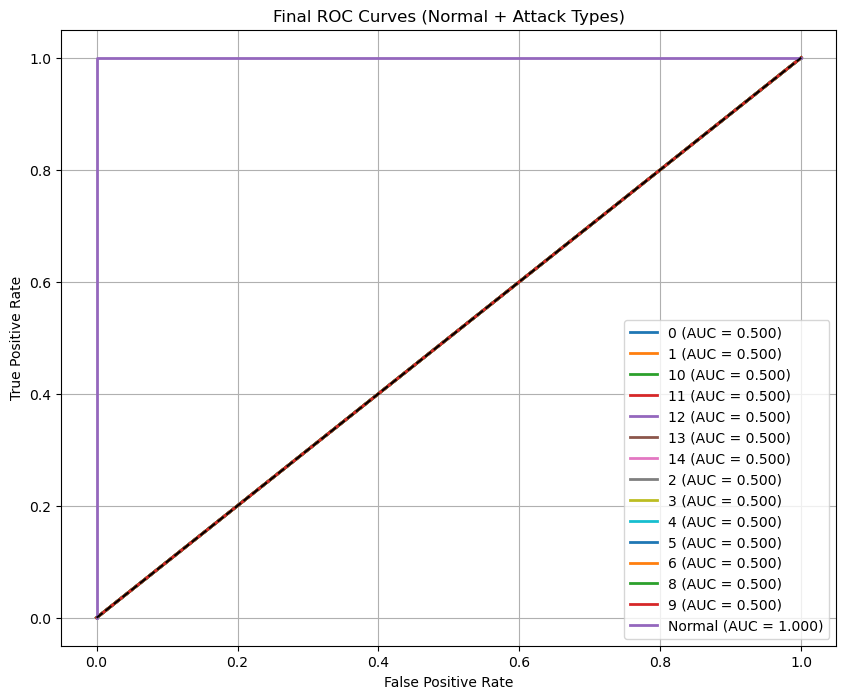

In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Unique classes in final output
classes = np.unique(np.concatenate([np.array(y_true_final), np.array(final_output)]))

# Binarize true labels
y_true_bin = label_binarize(y_true_final, classes=classes)

# Build probability matrix
final_probs = np.zeros((len(X_test), len(classes)))

# Probability of attack from stage 1
attack_prob = ytest_pred_prob.flatten()
normal_prob = 1 - attack_prob

# Map class names to column indices
class_index = {c:i for i,c in enumerate(classes)}

# Fill normal probabilities
if "Normal" in class_index:
    final_probs[:, class_index["Normal"]] = normal_prob

# Attack probabilities from stage 2
attack_prob_matrix = np.zeros((len(X_test), num_classes))

if len(attack_test_indices) > 0:
    attack_type_probs_full = model_type.predict(X_test[attack_test_indices])
    attack_prob_matrix[attack_test_indices] = attack_type_probs_full

# Combine stage 1 and stage 2 probabilities
for i, attack_name in enumerate(le.classes_):
    if attack_name in class_index:
        final_probs[:, class_index[attack_name]] = attack_prob * attack_prob_matrix[:, i]

# Plot ROC curves
plt.figure(figsize=(10,8))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curves (Normal + Attack Types)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()